In [1]:
import torch
from torch import nn

from copy import deepcopy

from explainer import vgg_lrps, resnet_lrps
from explainer.lrp_utils import layers_lookup

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import sys
sys.path.append(os.path.dirname(os.path.abspath(os.path.dirname('__file__'))))
import matplotlib.pyplot as plt
import re
import gc

from setting import *
from utils import load_trained_model, extract_vgg16_info

import torchvision
from torchvision import datasets, models, transforms

dataset_name = 'cub'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = 'vgg16'
nb_classes = 200

model, input_size = load_trained_model(model_name, dataset_name, nb_classes)
model.eval()
model.to(device)

norm_factor_mean = [0.485, 0.456, 0.406]
norm_factor_std = [0.229, 0.224, 0.225]

if dataset_name == 'cub':
    data_dir = '/archive/workspace/datasets/CUB_200_2011/split/'

elif dataset_name == 'imagenet':
    data_dir = '/archive/workspace/datasets/ILSVRC2012'


train_ds = datasets.ImageFolder(
    os.path.join(data_dir, 'train'), 
    torchvision.transforms.Compose([
        torchvision.transforms.Resize(size=(input_size, input_size)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=norm_factor_mean, 
                                         std=norm_factor_std)
    ]))

train_dl = torch.utils.data.DataLoader(train_ds,
                                       batch_size=sz_batch_train, 
                                       shuffle=True, 
                                       num_workers=4)

val_ds = datasets.ImageFolder(
    os.path.join(data_dir, 'val'), 
    torchvision.transforms.Compose([
        torchvision.transforms.Resize(size=(input_size, input_size)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=norm_factor_mean, 
                                         std=norm_factor_std)
    ]))

val_dl = torch.utils.data.DataLoader(val_ds,
                                     batch_size=10, 
                                     shuffle=False, 
                                     num_workers=4)

steps_of_train = int(len(train_ds)/sz_batch_train)
steps_of_val = int(len(val_ds)/sz_batch_val)

# model_info = extract_model_info(model, train_dl, device)

/archive/library/anaconda3/envs/xai/lib/python3.7/site-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/archive/library/anaconda3/envs/xai/lib/python3.7/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
lookup_table = layers_lookup()

class VGG_SLRP(nn.Module):
    def __init__(self, name, model, device, input_size, nb_classes, mode='z_plus', top_k=1.0):
        super().__init__()
        self.name = name
        self.model = model
        self.device = device
        self.input_size = input_size
        self.nb_classes = nb_classes
        self.mode = mode
        self.top_k = top_k
        
        self.activations = dict()
        self.gradients = dict()
        self.grad_batch = dict()
        
        self.layers, self.check_pt = self._disassemble_model()
        
    def _disassemble_model(self):
        vgg_num = int(re.sub(r'[^0-9]', '', self.name))
        
        layers = nn.ModuleDict()
        check_pt = list()
        idx = 0
        
        assert self.model != None, 'Model is None'
                
        for key, module in self.model.named_children():
            if 'avgpool' in key: 
                layers[str(idx)] = module; idx += 1
                layers[str(idx)] = torch.nn.Flatten(start_dim=1); idx += 1
            else:
                for m in module: 
                    layers[str(idx)] = m; idx += 1
                    if 'CONV' in m.__class__.__name__.upper(): check_pt.append(idx) 
            
        return layers, check_pt
    
    
    def _init_check_pt_shape(self):
        x_dump = torch.zeros([1, 3, self.input_size, self.input_size]).to(self.device)
        _ = self.forward(x_dump)
        
        shapes = {}
        for idx in self.check_pt:
            if idx in self.activations.keys():
                shapes[idx] = self.get_activation(idx).shape
            else:
                act_keys = list(self.activations.keys())
                for i, a_key in enumerate(act_keys):
                    if len(act_keys)-1 < i: break
                    if idx > act_keys[i] and idx < act_keys[i+1]:
                        shapes[idx] = self.layers[str(a_key)].activations[idx].shape
                        break
                        
        return shapes
                
    def _get_last_relevance(self, logits: torch.tensor, labels: torch.tensor) -> torch.tensor:
        if labels == None:
            labels = torch.argmax(logits, 1) # if labels is None, prediction is replaced by labels
        
        # logits = torch.softmax(logits, dim=-1)
        mask = torch.zeros_like(logits)
        for i, idx in enumerate(labels):
            mask[i, idx] = 1
            
        return logits * mask
    
    def get_activation(self, idx):
        assert len(self.activations) > 0, print('Not find activation dict')
        return self.activations[idx]
    
    def save_gradient(self, idx):
        def hook(grad):
            self.gradients[idx] = grad
        return hook
        
    @torch.no_grad()
    def forward(self, x):
        if len(self.activations) != 0:
            self.activations = dict()
        
        print(self.check_pt)
        # save input of each layer 
        for key, layer in self.layers.items():
            if int(key) == 0: self.activations[0] = torch.ones_like(x).data.requires_grad_(True)
            else: 
                self.activations[int(key)] = x
                # if int(key) in self.check_pt: 
                x.register_hook(self.save_gradient(int(key)))
            x = layer(x)
            
        self.activations[int(key)+1] = x
        
        return x
    
    def get_gradients(self, target_cls):
        grads = {}
        for i, t_cls in enumerate(target_cls): 
            t_cls.backward(retain_graph=True)
            for key, grad in self.gradients.items():
                if key in grads.keys(): grads[key] = torch.cat([grads[key], grad[i].unsqueeze(0)], 0)
                else: grads[key] = grad[i].unsqueeze(0)
                    
        return grads
        
    def relevance(self, r, y=None, s_idx=-1, t_idx=0):
        pred = None
        
        if s_idx == -1:
            last_activation = self.forward(r)
            post_logits = torch.softmax(last_activation, dim=-1)
            pred = torch.max(post_logits, 1) # [0]: max values, [1]: index
            self.grad_batch = self.get_gradients(pred[0])
            
            r = self._get_last_relevance(logits=last_activation.clone().detach(), 
                                         labels=y)
    
        pre_key = -1
        for key, layer in reversed(self.layers.items()):
            if s_idx == -1 or s_idx >= int(key):
                lrp_layer = lookup_table[layer.__class__](layer=deepcopy(layer), 
                                                               mode=self.mode,
                                                               top_k=self.top_k)
                a = self.activations[int(key)]
                r = lrp_layer(a=a.data.requires_grad_(True),
                              r=r)
                
                # if a.dim() == 2:
                #     grad = torch.where(self.grad_batch[int(key)] > 0, self.grad_batch[int(key)], 0.)
                #     grad_sum =  torch.sum(grad, 1).unsqueeze(1)
                #     grad /= grad_sum
                #     r *= grad.squeeze()
                # else:
                #     grad_avg_pool = torch.nn.AvgPool2d(self.grad_batch[int(key)].shape[-2:])(self.grad_batch[int(key)])
                #     grad_avg_pool = torch.where(grad_avg_pool > 0, grad_avg_pool, 0.).squeeze()
                #     grad_sum = torch.sum(grad_avg_pool, 1).unsqueeze(1)
                #     grad_avg_pool /= grad_sum
                #     grad_avg_pool = grad_avg_pool.unsqueeze(-1).unsqueeze(-1)
                #     r *= grad_avg_pool
                
            if t_idx == int(key): 
                grad_avg_pool = torch.nn.AvgPool2d(self.grad_batch[int(key)].shape[-2:])(self.grad_batch[int(key)])
                grad_avg_pool = torch.where(grad_avg_pool > 0, grad_avg_pool, 0.).squeeze()
                grad_sum = torch.sum(grad_avg_pool, 1).unsqueeze(1)
                grad_avg_pool /= grad_sum
                grad_avg_pool = grad_avg_pool.unsqueeze(-1).unsqueeze(-1)
                r *= grad_avg_pool
                break
                
        return r, a, pred

In [8]:
gc.collect()
torch.cuda.empty_cache()

lrp = VGG_SLRP(name=model_name, model=model, 
              device=device, input_size=input_size, 
              nb_classes=nb_classes)

In [9]:
for x_batch, y_batch in val_dl:  
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    
    r = None
    rs = []
    s_idx = -1
    t_idx = 0
    
    for idx in reversed(lrp.check_pt):
        print('idx: ', idx)

        if r == None: r = x_batch.clone().detach()
        else: s_idx = t_idx-1

        t_idx = idx

        r, a, _, = lrp.relevance(r=r, y=y_batch, s_idx=s_idx, t_idx=t_idx)
        rs.insert(0, r.clone().detach().cpu())
    
    break

idx:  29
[1, 3, 6, 8, 11, 13, 15, 18, 20, 22, 25, 27, 29]


RuntimeError: cannot register a hook on a tensor that doesn't require gradient

In [ ]:
row = 10
col = len(lrp.check_pt) + 1

uf = 3
fig, axs = plt.subplots(row, col, figsize=(col*uf, row*uf))

for b in range(row):
    for i in range(col):
        x = int(i/col) + b
        y = int(i%col) 
        
        if i == 0:
            img = x_batch[b].permute(1,2,0).squeeze().detach().cpu()
            axs[x,y].imshow(img)
        else:
            hm = rs[i-1][b].permute(1,2,0).max(dim=-1)[0].detach().cpu()
            axs[x,y].imshow(hm, vmin=-hm.max(), vmax=hm.max(), cmap='seismic')



In [3]:
model_info = extract_vgg16_info(model, train_dl, device)

In [8]:
class LRP(nn.Module):
    def __init__(self, layer_info, mode='z_plus', top_k=1.0):
        super().__init__()
        
        self.mode = mode
        self.top_k = top_k
        # self.eps = 1.0e-05
        
        self.layer_info = layer_info
        self.layer_info_keys = list(self.layer_info.keys())

        # Create LRP network
        self.lrp_layers = self._create_lrp_model()
        self.lrp_keys = list(self.lrp_layers.keys())
        
    def _create_lrp_model(self) -> torch.nn.ModuleList:
        """
            Method builds the model for layer-wise relevance propagation.
            
            Returns:
                LRP-model as module list.
        """
        lookup_table = layers_lookup()
        lrp_layers = {}
        
        for key in reversed(self.layer_info_keys):
            layers_by_key = self.layer_info[key]
            lrp_layer_by_key = nn.ModuleList()
            
            for layer in reversed(layers_by_key):
                try:
                    lrp_layer_by_key.append(lookup_table[layer.__class__](layer=deepcopy(layer),
                                                                          mode=self.mode,
                                                                          top_k=self.top_k))
                except KeyError:
                    message = f"Layer-wise relevance propagation not implemented for " \
                              f"{layer.__class__.__name__} layer."
                    raise NotImplementedError(messagesage)
            
            lrp_layers[key] = lrp_layer_by_key
            
        return lrp_layers
    
    def _get_last_relevance(self, logits: torch.tensor, labels: torch.tensor) -> torch.tensor:
        if labels == None:
            labels = torch.argmax(logits, 1) # if labels is None, prediction is replaced by labels
        
        mask = torch.zeros_like(logits)
        for i, idx in enumerate(labels):
            mask[i, idx] = 1
       
        return logits * mask
    
    def _get_rmap_before_feature_module(self, 
                                        x: torch.tensor,
                                        y: torch.tensor=None):
        # get all activations from target model on x
        activations = list()
        
        with torch.no_grad():
            activations.append(torch.ones_like(x))
            for key in self.layer_info_keys:
                for layer in self.layer_info[key]:
                    x = layer.forward(x)
                    activations.append(x)
                
        activations = activations[::-1]
        activations = [a.data.requires_grad_(True) for a in activations]
        
        last_activation = activations.pop(0)
        post_logits = torch.softmax(last_activation, dim=-1)
        pred_outputs = torch.max(post_logits, 1) # [0]: max values, [1]: index
        
        r = self._get_last_relevance(logits=last_activation.clone().detach(), 
                                     labels=y)
        
        for lrp_k in self.lrp_keys[:len(self.lrp_keys)-1]:
            lrp_layers_by_key = self.lrp_layers[lrp_k]
            for lrp_layer in lrp_layers_by_key:
                a = activations.pop(0)
                print("a: ", a.shape)
                print('r1: ', r.shape)
                r = lrp_layer.forward(a, r) 
                print('r2: ', r.shape)
                
        return r, a, pred_outputs, activations
    
    def _get_rmap_from_s_to_t(self, r, activations, s_idx, t_idx):
        lrp_layers_by_key = self.lrp_layers[self.lrp_keys[-1]]
        
        for i, lrp_layer in enumerate(lrp_layers_by_key):
            lrp_to_conv_idx = len(lrp_layers_by_key)-1-i
            
            if s_idx == -1 or lrp_to_conv_idx < s_idx:            
                print('lrp_to_conv_idx: ', lrp_to_conv_idx)
                print(lrp_layer)
                a = activations.pop(0)
                print('a: ', a.shape, a[0, 0, :5, :5])
                print('r1: ', r.shape)
                r = lrp_layer.forward(a, r) 
                print('r2: ', r.shape)
            
            if lrp_to_conv_idx == t_idx: break
        
        return r, a, activations
    
    def forward(self,
                r: torch.tensor,
                y: torch.tensor=None,
                acts: list=None,
                s_idx: int=-1, 
                t_idx: int=0):
        """
            Propagate relevance from s_idx to t_idx
            
            Args: 
                r: Input, which can be an images or intermediate relevances (N, C, H, W)
                y: Input label which will be used in case s_idx == -1
                acts: Remaining activations to be used for relevance prop 
                s_idx: Start index for relevance propagation
                t_idx: End index for relevance propagation
                
            Returns:
                r: Relevance in last conv layer
                a: Activation of the last conv layer
                p: Prediction list ([0]: predictiin values, [1]: prediction indice) / (B, nb_classes)
                acts: Remaining activations after last conv layer
        """
        p = None
        if s_idx == -1: # first relevance prop 
            r, a, p, acts = self._get_rmap_before_feature_module(r, y)
        r, a, acts = self._get_rmap_from_s_to_t(r, acts, s_idx, t_idx)
        
        return r, a, p, acts

In [16]:
lrp = LRP(layer_info=model_info['layer'])

for images, labels in val_dl:  
    images = images.to(device)
    labels = labels.to(device)
    
    r_lrp, a, p, acts = lrp.forward(r=images, t_idx=29)
    print(r_lrp.shape)
    
    break


a:  torch.Size([20, 4096])
r1:  torch.Size([20, 200])
r2:  torch.Size([20, 4096])
a:  torch.Size([20, 4096])
r1:  torch.Size([20, 4096])
r2:  torch.Size([20, 4096])
a:  torch.Size([20, 4096])
r1:  torch.Size([20, 4096])
r2:  torch.Size([20, 4096])
a:  torch.Size([20, 4096])
r1:  torch.Size([20, 4096])
r2:  torch.Size([20, 4096])
a:  torch.Size([20, 4096])
r1:  torch.Size([20, 4096])
r2:  torch.Size([20, 4096])
a:  torch.Size([20, 4096])
r1:  torch.Size([20, 4096])
r2:  torch.Size([20, 4096])
a:  torch.Size([20, 25088])
r1:  torch.Size([20, 4096])
r2:  torch.Size([20, 25088])
a:  torch.Size([20, 512, 7, 7])
r1:  torch.Size([20, 25088])
r2:  torch.Size([20, 512, 7, 7])
a:  torch.Size([20, 512, 7, 7])
r1:  torch.Size([20, 512, 7, 7])
r2:  torch.Size([20, 512, 7, 7])
lrp_to_conv_idx:  30
RelevancePropagationMaxPool2d(
  (layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
a:  torch.Size([20, 512, 14, 14]) tensor([[0.0000, 0.0000, 0.1226, 0.0000, 0.0077],
  

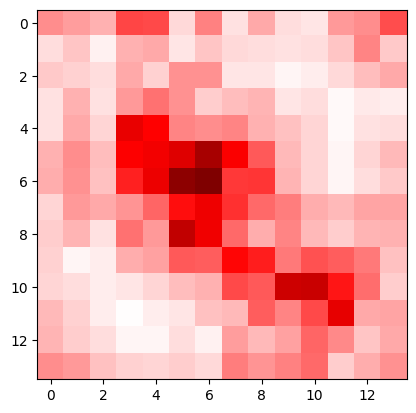

In [17]:
r_lrp0 = r_lrp[0].permute(1,2,0).max(dim=-1)[0].detach().cpu().numpy()
plt.imshow(r_lrp0, vmin=-r_lrp0.max(), vmax=r_lrp0.max(), cmap='seismic')

In [320]:
class CLRP(LRP):
    def __init__(self, layer_info, mode='z_plus', top_k=1.0):
        super().__init__(layer_info, mode='z_plus', top_k=1.0)
    
    def _get_last_relevance_T(self, logits: torch.tensor, labels: torch.tensor) -> torch.tensor:
        if labels == None:
            labels = torch.argmax(logits, 1) # if labels is None, prediction is replaced by labels
        
        mask = torch.zeros_like(logits)
        for i, idx in enumerate(labels):
            mask[i, idx] = 1
       
        return logits * mask 
        
    def _get_last_relevance_D(self, logits: torch.tensor, labels: torch.tensor) -> torch.tensor:
        if labels == None:
            labels = torch.argmax(logits, 1) 
        
        mask = torch.ones_like(logits)
        _,  n = logits.shape

        for i, idx in enumerate(labels):
            mask[i, idx] = 0
            logits[i].data *= -1 * (1 / (n-1))

        return logits * mask
    
    def _get_last_relevance(self, logits: torch.tensor, labels: torch.tensor) -> torch.tensor:
        r_T = self._get_last_relevance_T(logits, labels)
        r_D = self._get_last_relevance_D(logits, labels)
        
        return r_T + r_D
    

In [321]:
clrp = CLRP(layer_info=model_info['layer'])

for images, labels in val_dl:  
    images = images.to(device)
    labels = labels.to(device)
    
    r_clrp, a, acts = clrp.forward(x=images)
    
    break


y:  None
lrp_to_conv_idx:  30
	 lrp_layer:  RelevancePropagationMaxPool2d(
  (layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
lrp_to_conv_idx:  29
	 lrp_layer:  RelevancePropagationReLU()
lrp_to_conv_idx:  28
	 lrp_layer:  RelevancePropagationConv2d(
  (layer): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
lrp_to_conv_idx:  27
	 lrp_layer:  RelevancePropagationReLU()
lrp_to_conv_idx:  26
	 lrp_layer:  RelevancePropagationConv2d(
  (layer): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
lrp_to_conv_idx:  25
	 lrp_layer:  RelevancePropagationReLU()
lrp_to_conv_idx:  24
	 lrp_layer:  RelevancePropagationConv2d(
  (layer): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
lrp_to_conv_idx:  23
	 lrp_layer:  RelevancePropagationMaxPool2d(
  (layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
lrp_to_conv_idx:  22
	 lrp_layer:  RelevancePropagationReLU()
lrp

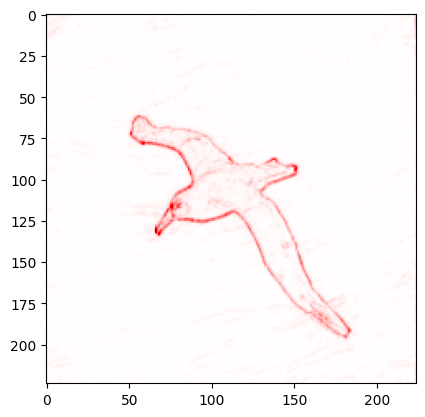

In [322]:
r_clrp0 = r_clrp[0].permute(1,2,0).max(dim=-1)[0].detach().cpu().numpy()
plt.imshow(r_clrp0, vmin=-r_clrp0.max(), vmax=r_clrp0.max(), cmap='seismic')

In [323]:
class SGLRP(LRP):
    def __init__(self, layer_info, mode='z_plus', top_k=1.0):
        super().__init__(layer_info, mode='z_plus', top_k=1.0)
    
    def _get_last_relevance_T(self, logits: torch.tensor, labels: torch.tensor) -> torch.tensor:
        if labels == None:
            labels = torch.argmax(logits, 1) # if labels is None, prediction is replaced by labels
        
        logits = torch.softmax(logits, dim=-1)
        mask = torch.zeros_like(logits)  
        
        for i, idx in enumerate(labels):
            mask[i, idx] = 1
            logits[i] = logits[i] * (1 - logits[i, idx].item())
        
        return logits * mask
        
    def _get_last_relevance_D(self, logits: torch.tensor, labels: torch.tensor) -> torch.tensor:
        if labels == None:
            labels = torch.argmax(logits, 1) 
        
        logits = torch.softmax(logits, dim=-1)
        mask = torch.ones_like(logits)
        
        for i, idx in enumerate(labels):
            mask[i, idx] = 0
            logits[i] = -1 * (logits[i] * logits[i, idx].item())
                                                                                               
        return logits * mask
    
    def _get_last_relevance(self, logits: torch.tensor, labels: torch.tensor) -> torch.tensor:
        r_T = self._get_last_relevance_T(logits, labels)
        r_D = self._get_last_relevance_D(logits, labels)
        
        return r_T + r_D
    

In [324]:
sglrp = SGLRP(layer_info=model_info['layer'])

for images, labels in val_dl:  
    images = images.to(device)
    labels = labels.to(device)
    
    r, a, acts = sglrp.forward(x=images)
    print(r.shape)
    
    break


y:  None
lrp_to_conv_idx:  30
	 lrp_layer:  RelevancePropagationMaxPool2d(
  (layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
lrp_to_conv_idx:  29
	 lrp_layer:  RelevancePropagationReLU()
lrp_to_conv_idx:  28
	 lrp_layer:  RelevancePropagationConv2d(
  (layer): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
lrp_to_conv_idx:  27
	 lrp_layer:  RelevancePropagationReLU()
lrp_to_conv_idx:  26
	 lrp_layer:  RelevancePropagationConv2d(
  (layer): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
lrp_to_conv_idx:  25
	 lrp_layer:  RelevancePropagationReLU()
lrp_to_conv_idx:  24
	 lrp_layer:  RelevancePropagationConv2d(
  (layer): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
lrp_to_conv_idx:  23
	 lrp_layer:  RelevancePropagationMaxPool2d(
  (layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
lrp_to_conv_idx:  22
	 lrp_layer:  RelevancePropagationReLU()
lrp

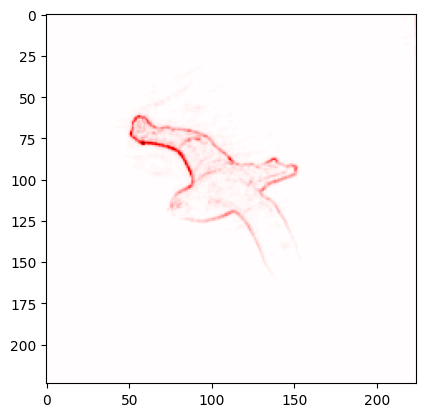

In [325]:
r0 = r[0].permute(1,2,0).max(dim=-1)[0].detach().cpu()
plt.imshow(r0, vmin=-r0.max(), vmax=r0.max(), cmap='seismic')

torch.Size([56, 56])


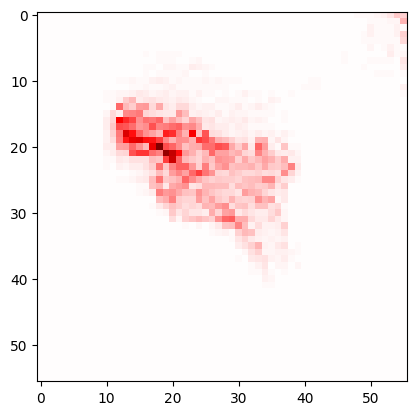

In [270]:
relu = torch.nn.ReLU()
r0 = relu(r0)
print(r0.shape)
plt.imshow(r0, vmin=-r0.max(), vmax=r0.max(), cmap='seismic')